
# Fully Connected Neural Network for Devnagari Handwritten Digit Classification



---
## Setup – Install / Import Libraries

In [73]:
#  Core imports
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

# PIL for image loading
from PIL import Image

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Scikit-learn for metrics
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print(f"TensorFlow version : {tf.__version__}")
print(f"Keras version      : {keras.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.19.0
Keras version      : 3.13.2
GPU available      : False


In [74]:
import zipfile
import os
from tqdm import tqdm

def extract_zip_with_progress(zip_path, extract_to='/content'):
    """Extract ZIP file with a progress bar."""
    os.makedirs(extract_to, exist_ok=True)

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        members = zip_ref.infolist()
        total = len(members)

        print(f"📦 Found {total} files | Size: {sum(m.file_size for m in members) / 1e6:.1f} MB")

        for member in tqdm(members, desc="Extracting", unit="file"):
            zip_ref.extract(member, extract_to)

    print(f"Done! Files saved to: {extract_to}")

# Usage
extract_zip_with_progress('/content/drive/MyDrive/Semester6_AI ML/Week 4/Copy of devnagari digit.zip', '/content/output')

📦 Found 20000 files | Size: 12.0 MB


Extracting: 100%|██████████| 20000/20000 [00:03<00:00, 6117.71file/s]


Done! Files saved to: /content/output


In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Task 1 – Data Preparation


In [76]:
# Define dataset paths (update these paths if your dataset is elsewhere)
TRAIN_DIR = "/content/output/DevanagariHandwrittenDigitDataset/Train"
TEST_DIR  = "/content/output/DevanagariHandwrittenDigitDataset/Test"

# Target image dimensions
IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

def load_images_from_folder(folder, img_height=28, img_width=28):
    """
    Loads images from a folder with subdirectories as class labels.
    Each subdirectory name maps to an integer label (0-9).

    Returns
    -------
    images : np.ndarray  shape (N, img_height, img_width)
    labels : np.ndarray  shape (N,)  — integer class indices
    """
    images = []
    labels = []

    # Sort so that class indices are consistent across runs
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}
    print(f"Classes found in '{folder}': {class_map}")

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert("L")
                img = img.resize((img_width, img_height))
                img_array = np.array(img) / 255.0
                images.append(img_array)
                labels.append(label)
            except Exception as e:
                print(f"Skipping {img_path}: {e}")

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32)


#  Load datasets
print("Loading training data …")
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR, IMG_HEIGHT, IMG_WIDTH)

print("\nLoading test data …")
x_test_raw, y_test_raw   = load_images_from_folder(TEST_DIR,  IMG_HEIGHT, IMG_WIDTH)

#  Flatten images: (N, 28, 28) → (N, 784) for FCN
x_train_flat = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test_flat  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)

#  One-hot encode labels
y_train_ohe = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test_ohe  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

#  Dataset summary
print(f"\n{'─'*50}")
print(f"Training images  : {x_train_flat.shape}")
print(f"Training labels  : {y_train_ohe.shape}")
print(f"Test images      : {x_test_flat.shape}")
print(f"Test labels      : {y_test_ohe.shape}")
print(f"Pixel value range: [{x_train_flat.min():.2f}, {x_train_flat.max():.2f}]")

Loading training data …
Classes found in '/content/output/DevanagariHandwrittenDigitDataset/Train': {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Loading test data …
Classes found in '/content/output/DevanagariHandwrittenDigitDataset/Test': {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

──────────────────────────────────────────────────
Training images  : (17000, 784)
Training labels  : (17000, 10)
Test images      : (3000, 784)
Test labels      : (3000, 10)
Pixel value range: [0.00, 1.00]


In [77]:
#  Load training data
print("Loading TRAINING data …")
x_train_raw, y_train_raw = load_images_from_folder(TRAIN_DIR)

#  Load test data
print("\nLoading TEST data …")
x_test_raw, y_test_raw = load_images_from_folder(TEST_DIR)

print(f"\nTraining images : {x_train_raw.shape}  |  Labels: {y_train_raw.shape}")
print(f"Test images     : {x_test_raw.shape}   |  Labels: {y_test_raw.shape}")

Loading TRAINING data …
Classes found in '/content/output/DevanagariHandwrittenDigitDataset/Train': {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Loading TEST data …
Classes found in '/content/output/DevanagariHandwrittenDigitDataset/Test': {'digit_0': 0, 'digit_1': 1, 'digit_2': 2, 'digit_3': 3, 'digit_4': 4, 'digit_5': 5, 'digit_6': 6, 'digit_7': 7, 'digit_8': 8, 'digit_9': 9}

Training images : (17000, 28, 28)  |  Labels: (17000,)
Test images     : (3000, 28, 28)   |  Labels: (3000,)


In [78]:
#  Reshape for Keras  (N, H, W) → (N, H, W, 1)
x_train = x_train_raw.reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
x_test  = x_test_raw.reshape(-1, IMG_HEIGHT,  IMG_WIDTH, 1)

#  One-hot encode labels
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f"x_train : {x_train.shape}  (dtype={x_train.dtype})")
print(f"y_train : {y_train.shape}  (one-hot encoded)")
print(f"x_test  : {x_test.shape}")
print(f"y_test  : {y_test.shape}")
print(f"Pixel range  → min={x_train.min():.2f}, max={x_train.max():.2f}")

x_train : (17000, 28, 28, 1)  (dtype=float32)
y_train : (17000, 10)  (one-hot encoded)
x_test  : (3000, 28, 28, 1)
y_test  : (3000, 10)
Pixel range  → min=0.00, max=1.00


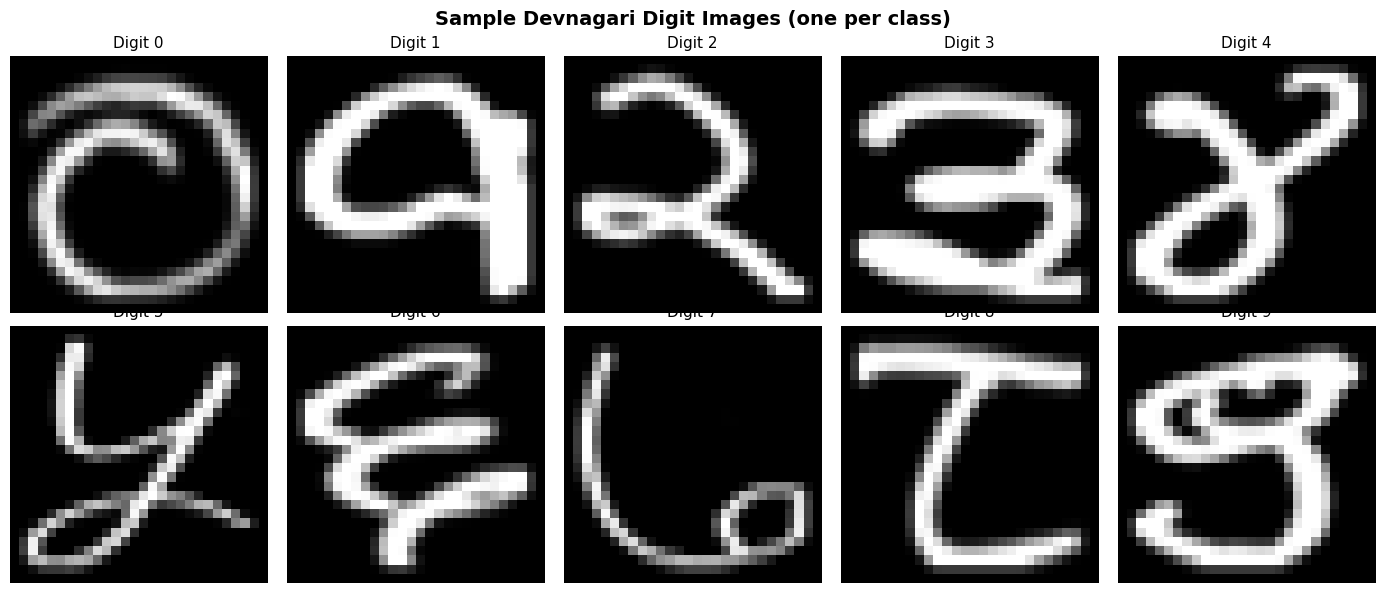

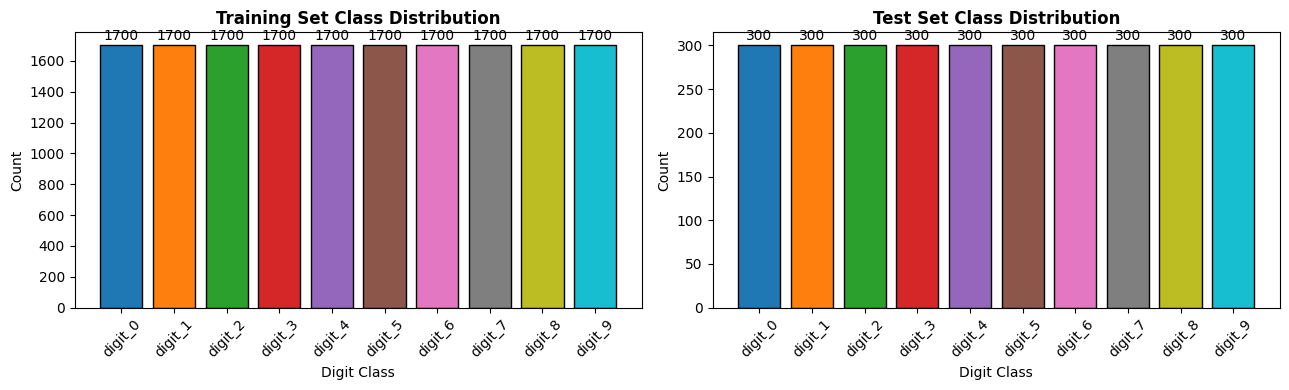

In [79]:
#  Visualise sample images from each class
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle("Sample Devnagari Digit Images (one per class)", fontsize=14, fontweight='bold')

for digit in range(NUM_CLASSES):
    ax = axes[digit // 5][digit % 5]
    # Find first occurrence of this digit in training set
    idx = np.where(y_train_raw == digit)[0][0]
    ax.imshow(x_train[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    ax.set_title(f"Digit {digit}", fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, (split_labels, title) in zip(axes, [
    (y_train_raw, "Training Set Class Distribution"),
    (y_test_raw,  "Test Set Class Distribution")
]):
    unique, counts = np.unique(split_labels, return_counts=True)
    bars = ax.bar([f"digit_{i}" for i in unique], counts,
                  color=plt.cm.tab10(unique / 10), edgecolor='black')
    ax.bar_label(bars, padding=2)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Digit Class")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

---
## Task 2 – Build the Fully Connected Network (FCN) Model

Architecture as specified in the worksheet:

| Layer | Type | Neurons | Activation |
|-------|------|---------|------------|
| Input | (32, 32, 1) | – | – |
| Flatten | – | 1024 | – |
| Hidden 1 | Dense | 64 | Sigmoid |
| Hidden 2 | Dense | 128 | Sigmoid |
| Hidden 3 | Dense | 256 | Sigmoid |
| Output | Dense | 10 | Softmax |

In [80]:
#  Build model using Sequential API
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 1)

model = keras.Sequential(
    [
        # Input specification
        keras.layers.Input(shape=INPUT_SHAPE, name="input_layer"),

        # Flatten 32×32×1 → 1024 vector
        keras.layers.Flatten(name="flatten"),

        # Hidden layer 1
        keras.layers.Dense(64,  activation="sigmoid", name="hidden_1"),

        # Hidden layer 2
        keras.layers.Dense(128, activation="sigmoid", name="hidden_2"),

        # Hidden layer 3
        keras.layers.Dense(256, activation="sigmoid", name="hidden_3"),

        # Output layer – 10 classes, softmax probabilities
        keras.layers.Dense(NUM_CLASSES, activation="softmax", name="output_layer"),
    ],
    name="devnagari_fcn"
)

# Print model summary
model.summary()

Model: "devnagari_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

---
## Task 3 – Compile the Model

- **Optimiser:** Adam (adaptive learning-rate, general-purpose)
- **Loss:** `categorical_crossentropy` (labels are one-hot encoded)
- **Metric:** Accuracy

In [81]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")
print(f"  Optimiser : Adam  (lr=0.001)")
print(f"  Loss      : categorical_crossentropy")
print(f"  Metrics   : accuracy")

Model compiled successfully!
  Optimiser : Adam  (lr=0.001)
  Loss      : categorical_crossentropy
  Metrics   : accuracy


---
## Task 4 – Train the Model

- Batch size: **128**
- Epochs: **20**
- Validation split: **20%**
- Callbacks: `ModelCheckpoint` + `EarlyStopping`

In [82]:
# Training hyper-parameters
BATCH_SIZE       = 128
EPOCHS           = 20
VALIDATION_SPLIT = 0.2

#  Callbacks
os.makedirs("checkpoints", exist_ok=True)

callbacks = [
    # Save the best model (by val_accuracy) during training
    keras.callbacks.ModelCheckpoint(
        filepath="checkpoints/best_model.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    # Stop early if val_loss doesn't improve for 5 consecutive epochs
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when plateau detected
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
]

print(f"Training for up to {EPOCHS} epochs  |  batch_size={BATCH_SIZE}  |  val_split={VALIDATION_SPLIT}")
print("-" * 70)

#  Train
history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=VALIDATION_SPLIT,
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")

Training for up to 20 epochs  |  batch_size=128  |  val_split=0.2
----------------------------------------------------------------------
Epoch 1/20
 96/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2740 - loss: 2.0039
Epoch 1: val_accuracy improved from None to 0.00000, saving model to checkpoints/best_model.keras

Epoch 1: finished saving model to checkpoints/best_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4803 - loss: 1.6105 - val_accuracy: 0.0000e+00 - val_loss: 6.7059 - learning_rate: 0.0010
Epoch 2/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8081 - loss: 0.6283
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8338 - loss: 0.5070 - val_accuracy: 0.0000e+00 - val_loss: 7.7386 - learning_rate: 0.0010
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9026 - loss: 0.3030
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy

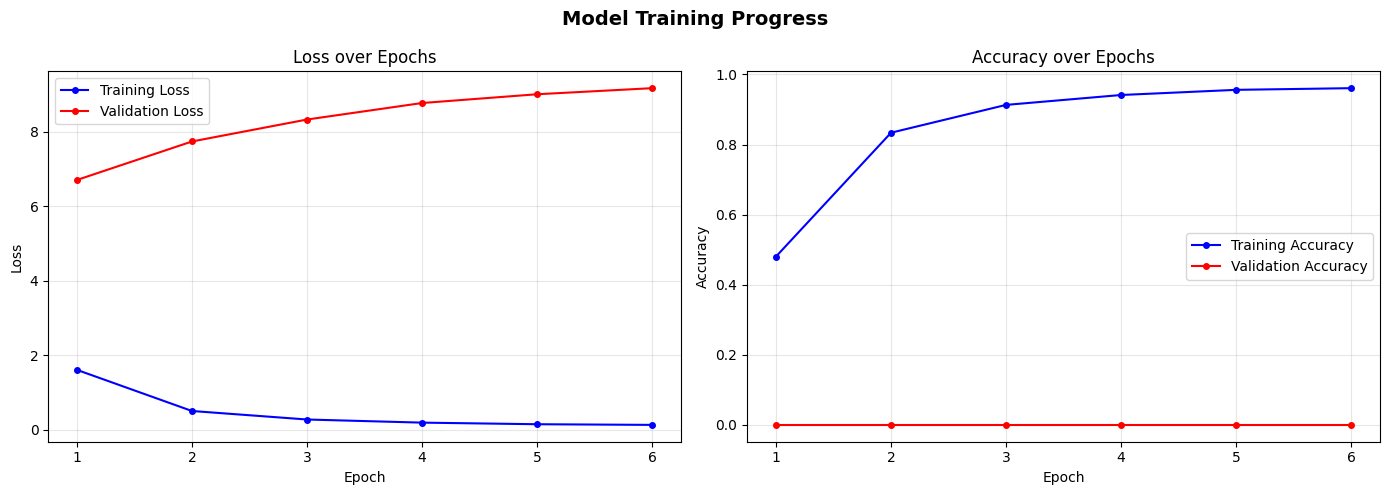

Best training accuracy   : 0.9609
Best validation accuracy : 0.0000


In [83]:
#  Visualise Training History
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']
epochs_ran = range(1, len(train_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Training Progress", fontsize=14, fontweight='bold')

# Loss plot
axes[0].plot(epochs_ran, train_loss, 'b-o', label='Training Loss',   markersize=4)
axes[0].plot(epochs_ran, val_loss,   'r-o', label='Validation Loss', markersize=4)
axes[0].set_title('Loss over Epochs')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(epochs_ran, train_acc, 'b-o', label='Training Accuracy',   markersize=4)
axes[1].plot(epochs_ran, val_acc,   'r-o', label='Validation Accuracy', markersize=4)
axes[1].set_title('Accuracy over Epochs')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best training accuracy   : {max(train_acc):.4f}")
print(f"Best validation accuracy : {max(val_acc):.4f}")

---
## Task 5 – Evaluate the Model on the Test Set

In [84]:
#  Evaluate on held-out test set
print("Evaluating on test set …")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"  Test Loss     : {test_loss:.4f}")
print(f"  Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")


Evaluating on test set …
94/94 - 0s - 3ms/step - accuracy: 0.6113 - loss: 2.0051
  Test Loss     : 2.0051
  Test Accuracy : 0.6113  (61.13%)


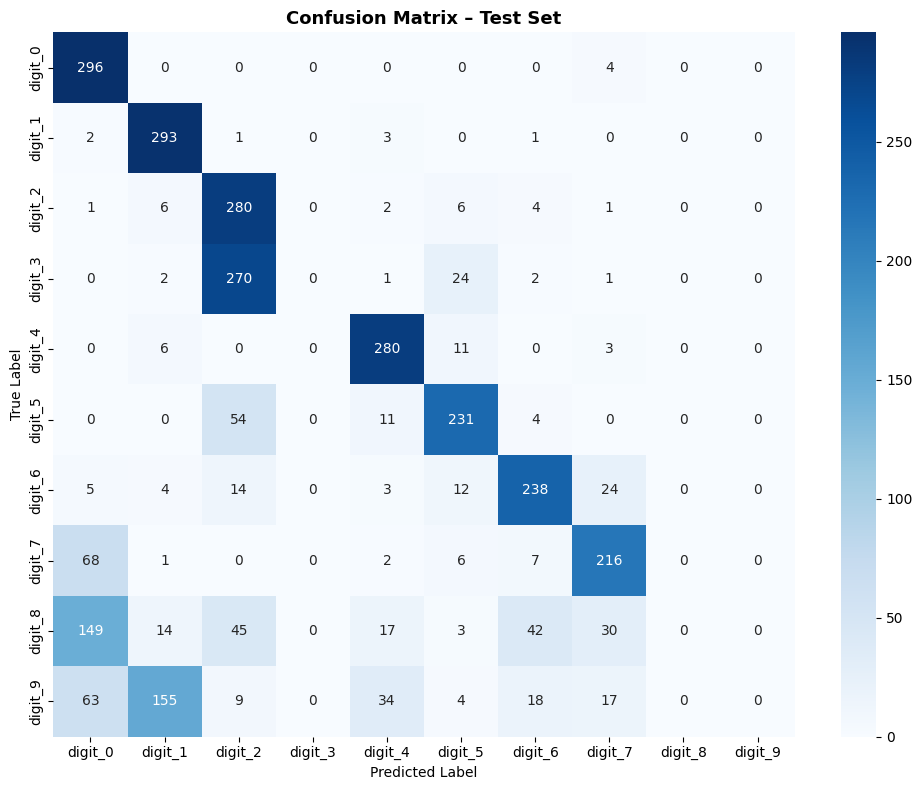


Classification Report:
              precision    recall  f1-score   support

     digit_0       0.51      0.99      0.67       300
     digit_1       0.61      0.98      0.75       300
     digit_2       0.42      0.93      0.58       300
     digit_3       0.00      0.00      0.00       300
     digit_4       0.79      0.93      0.86       300
     digit_5       0.78      0.77      0.77       300
     digit_6       0.75      0.79      0.77       300
     digit_7       0.73      0.72      0.72       300
     digit_8       0.00      0.00      0.00       300
     digit_9       0.00      0.00      0.00       300

    accuracy                           0.61      3000
   macro avg       0.46      0.61      0.51      3000
weighted avg       0.46      0.61      0.51      3000



In [85]:
#  Confusion Matrix
y_pred_probs  = model.predict(x_test, verbose=0)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test,       axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=[f"digit_{i}" for i in range(NUM_CLASSES)],
    yticklabels=[f"digit_{i}" for i in range(NUM_CLASSES)]
)
plt.title('Confusion Matrix – Test Set', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

#  Per-class classification report
print("\nClassification Report:")
print(classification_report(
    y_true_labels, y_pred_labels,
    target_names=[f"digit_{i}" for i in range(NUM_CLASSES)]
))

---
## Task 6 – Save and Load the Model

In [86]:
#  Save the trained model
MODEL_PATH = "devnagari_fcn_model.h5"
model.save(MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")
print(f"File size      : {os.path.getsize(MODEL_PATH) / 1024:.1f} KB")

Model saved to: devnagari_fcn_model.h5
File size      : 1141.5 KB


In [87]:
#  Load the saved model
loaded_model = tf.keras.models.load_model(MODEL_PATH)
print(f"Model loaded successfully from: {MODEL_PATH}")
loaded_model.summary()

Model loaded successfully from: devnagari_fcn_model.h5


Model: "devnagari_fcn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [88]:
#  Re-evaluate with loaded model to confirm weights are intact
print("Re-evaluating with the loaded model …")
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print("\n" + "=" * 45)
print(f"  Loaded Model – Test Loss     : {loaded_loss:.4f}")
print(f"  Loaded Model – Test Accuracy : {loaded_acc:.4f}  ({loaded_acc*100:.2f}%)")
print("=" * 45)

# Verify results match original model
match = np.isclose(test_acc, loaded_acc, atol=1e-6)
print(f"\nResults match original model: {match} ✓" if match else "\nWARNING: Results differ!")

Re-evaluating with the loaded model …
94/94 - 1s - 6ms/step - accuracy: 0.6113 - loss: 2.0051

  Loaded Model – Test Loss     : 2.0051
  Loaded Model – Test Accuracy : 0.6113  (61.13%)

Results match original model: True ✓


---
## Task 7 – Make Predictions and Interpret Results

In [89]:
#  Predictions on entire test set
predictions    = model.predict(x_test, verbose=0)
predicted_lbls = np.argmax(predictions, axis=1)
true_lbls      = np.argmax(y_test,      axis=1)

# First image
print(f"Predicted label for first test image : digit_{predicted_lbls[0]}")
print(f"True label for first test image      : digit_{true_lbls[0]}")
print(f"Prediction correct                   : {predicted_lbls[0] == true_lbls[0]}")

# Confidence (probability) of top prediction
print(f"\nProbability distribution for first image:")
for digit, prob in enumerate(predictions[0]):
    bar = '█' * int(prob * 40)
    print(f"  digit_{digit}: {prob:.4f}  {bar}")

Predicted label for first test image : digit_0
True label for first test image      : digit_0
Prediction correct                   : True

Probability distribution for first image:
  digit_0: 0.6167  ████████████████████████
  digit_1: 0.0413  █
  digit_2: 0.0054  
  digit_3: 0.0049  
  digit_4: 0.0062  
  digit_5: 0.0031  
  digit_6: 0.0591  ██
  digit_7: 0.2622  ██████████
  digit_8: 0.0006  
  digit_9: 0.0006  


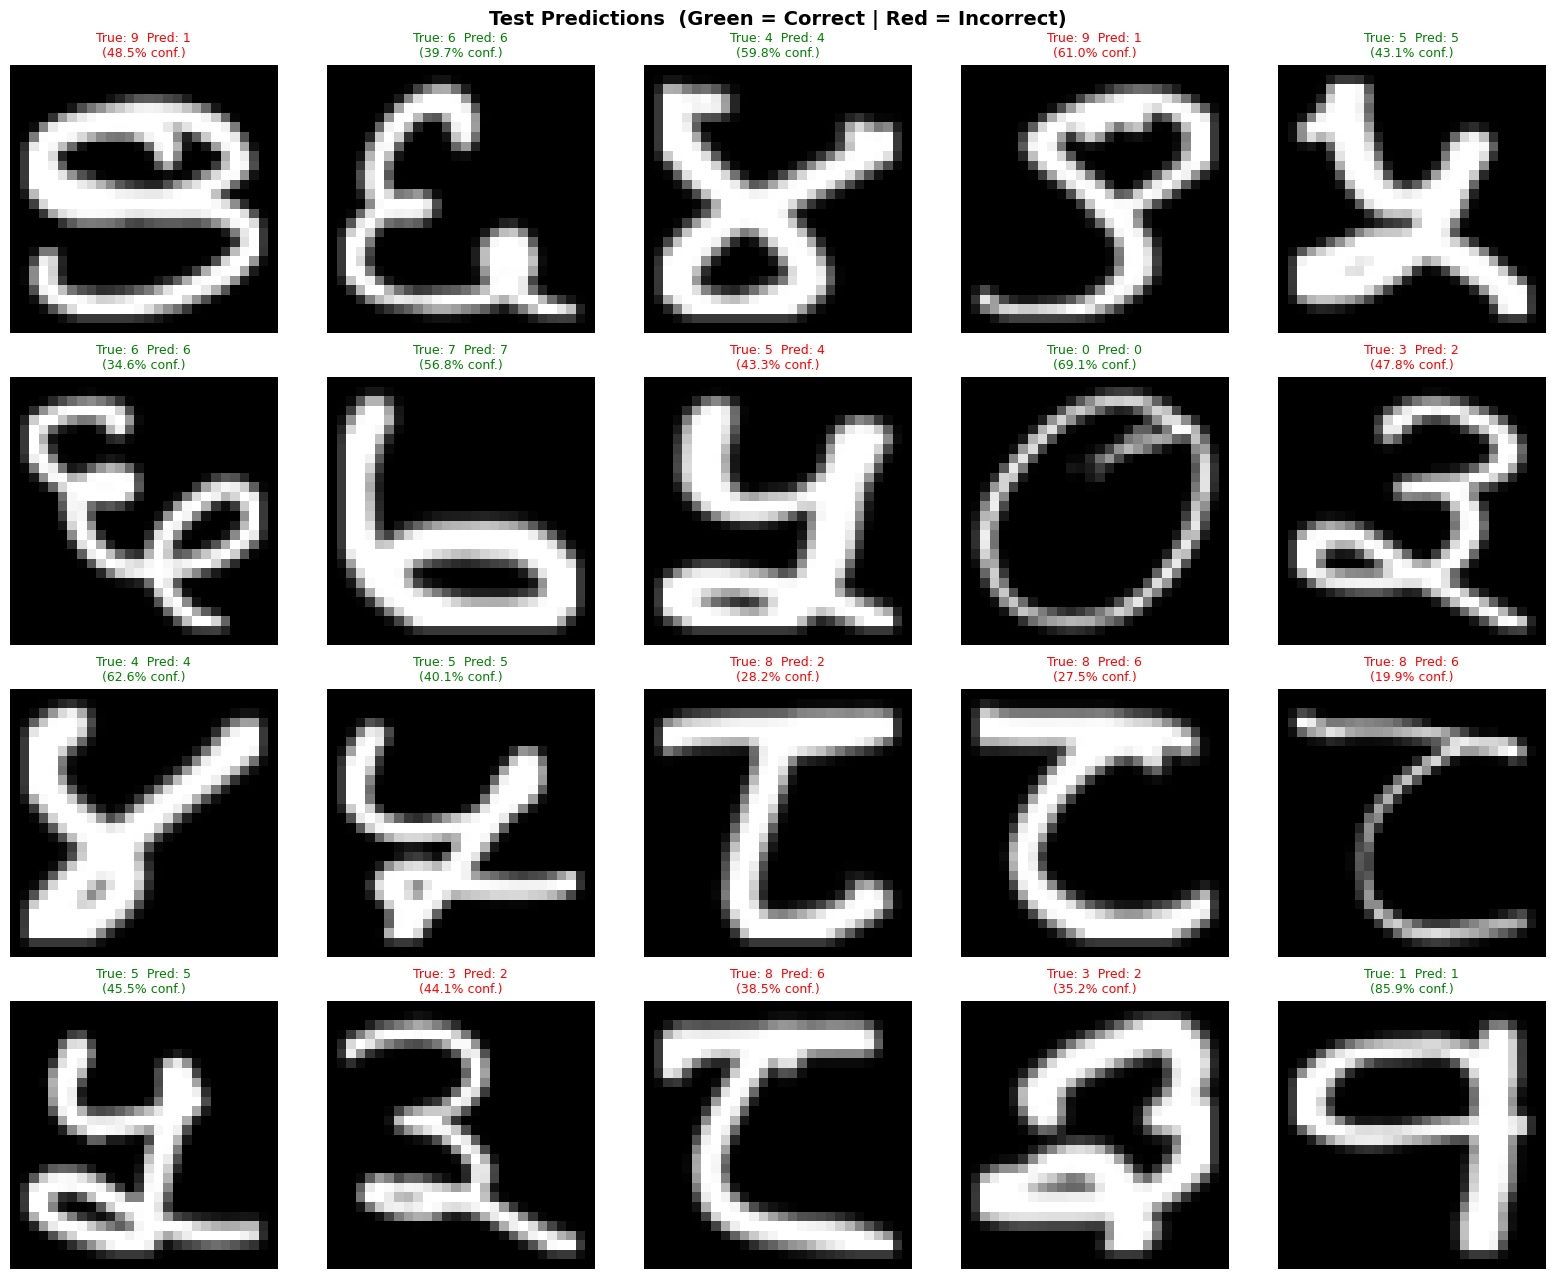

In [90]:
#  Visualise 20 test predictions (correct = green border, wrong = red border)
n_show = 20
indices = np.random.choice(len(x_test), n_show, replace=False)

fig, axes = plt.subplots(4, 5, figsize=(16, 13))
fig.suptitle("Test Predictions  (Green = Correct | Red = Incorrect)",
             fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flat, indices):
    ax.imshow(x_test[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')

    pred  = predicted_lbls[idx]
    true  = true_lbls[idx]
    color = 'green' if pred == true else 'red'

    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

    conf = predictions[idx][pred] * 100
    ax.set_title(f"True: {true}  Pred: {pred}\n({conf:.1f}% conf.)",
                 color=color, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

Total misclassified: 1166 / 3000


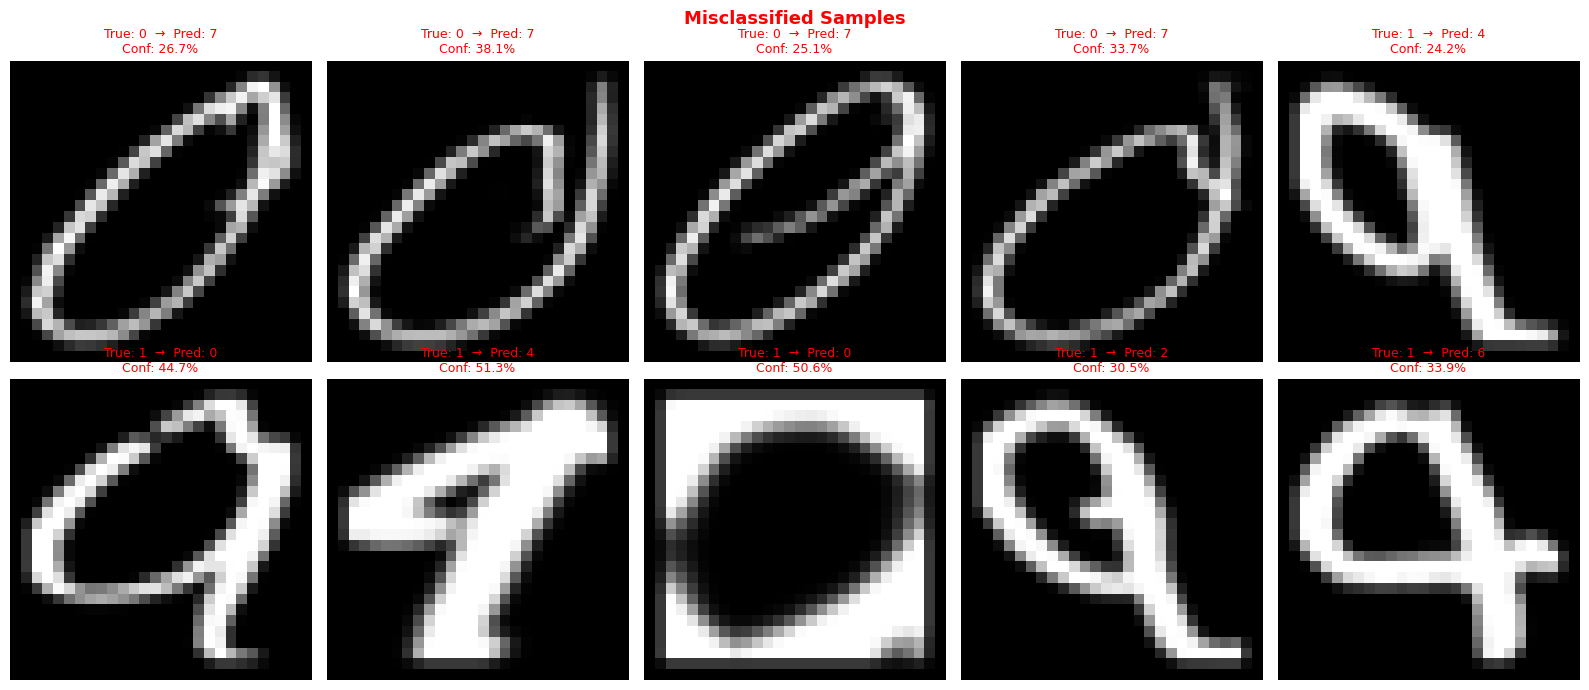

In [91]:
#  Show misclassified samples
wrong_idx = np.where(predicted_lbls != true_lbls)[0]
print(f"Total misclassified: {len(wrong_idx)} / {len(x_test)}")

show_wrong = min(10, len(wrong_idx))
if show_wrong > 0:
    fig, axes = plt.subplots(2, 5, figsize=(16, 7))
    fig.suptitle("Misclassified Samples", fontsize=13, fontweight='bold', color='red')

    for ax, idx in zip(axes.flat, wrong_idx[:show_wrong]):
        ax.imshow(x_test[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
        ax.set_title(
            f"True: {true_lbls[idx]}  →  Pred: {predicted_lbls[idx]}\n"
            f"Conf: {predictions[idx][predicted_lbls[idx]]*100:.1f}%",
            color='red', fontsize=9
        )
        ax.axis('off')

    # Hide unused axes if < 10 wrong
    for ax in axes.flat[show_wrong:]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No misclassifications on this test set – perfect score!")

---
## Summary & Results

In [92]:


print(f"  Dataset          : Devnagari Handwritten Digits")
print(f"  Image size       : {IMG_HEIGHT} × {IMG_WIDTH} (grayscale)")
print(f"  Training samples : {x_train.shape[0]}")
print(f"  Test samples     : {x_test.shape[0]}")
print()
print(f"  Architecture     : FCN (Flatten → 64 → 128 → 256 → 10)")
print(f"  Activations      : Sigmoid (hidden) | Softmax (output)")
print(f"  Optimiser        : Adam  (lr=0.001)")
print(f"  Loss function    : Categorical Cross-Entropy")
print(f"  Epochs trained   : {len(history.history['loss'])}")
print(f"  Batch size       : {BATCH_SIZE}")
print()
print(f"  Best Val Accuracy: {max(history.history['val_accuracy']):.4f}  "
      f"({max(history.history['val_accuracy'])*100:.2f}%)")
print(f"  Test Accuracy    : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"  Test Loss        : {test_loss:.4f}")
print(f"  Misclassified    : {len(wrong_idx)} / {len(x_test)}")
print()
print(f"  Model saved to   : {MODEL_PATH}")


  Dataset          : Devnagari Handwritten Digits
  Image size       : 28 × 28 (grayscale)
  Training samples : 17000
  Test samples     : 3000

  Architecture     : FCN (Flatten → 64 → 128 → 256 → 10)
  Activations      : Sigmoid (hidden) | Softmax (output)
  Optimiser        : Adam  (lr=0.001)
  Loss function    : Categorical Cross-Entropy
  Epochs trained   : 6
  Batch size       : 128

  Best Val Accuracy: 0.0000  (0.00%)
  Test Accuracy    : 0.6113  (61.13%)
  Test Loss        : 2.0051
  Misclassified    : 1166 / 3000

  Model saved to   : devnagari_fcn_model.h5
